In [ ]:
pip install pandas numpy scikit-learn xgboost shap lime matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [3]:
# 1. Load Dataset
df = pd.read_csv(r"C:\Users\19452\OneDrive\Documents\Personal\O1\XAI PAPER\diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [4]:
# 2. Train-Test Split & Scaling (Crucial for Logistic Regression & LIME)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Convert back to DataFrame to preserve feature names for SHAP/LIME
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [10]:
# 3. Model Initialization & Training
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

print("--- MODEL EVALUATION ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    print(f"\n[{name}]")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))

# --- SELECT BEST MODEL FOR XAI & PLOTS ---
best_model = models["XGBoost"]

--- MODEL EVALUATION ---

[Logistic Regression]
Accuracy: 0.7359
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231


[Random Forest]
Accuracy: 0.7576
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       151
           1       0.65      0.66      0.65        80

    accuracy                           0.76       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.76      0.76       231


[XGBoost]
Accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       151
           1       0.60      0.65      0.62        80

    accuracy                           0.73       231
 

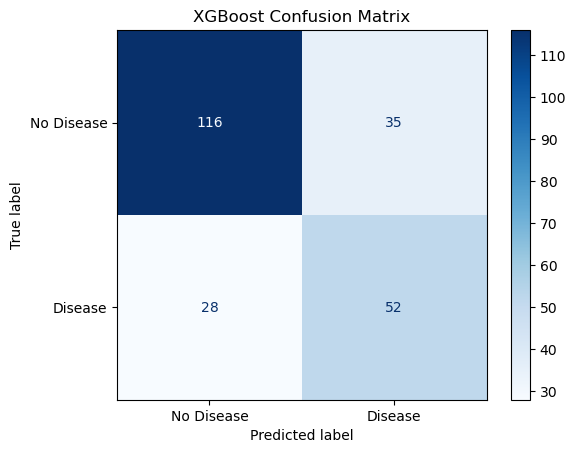

In [11]:
# 4. Confusion Matrix
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

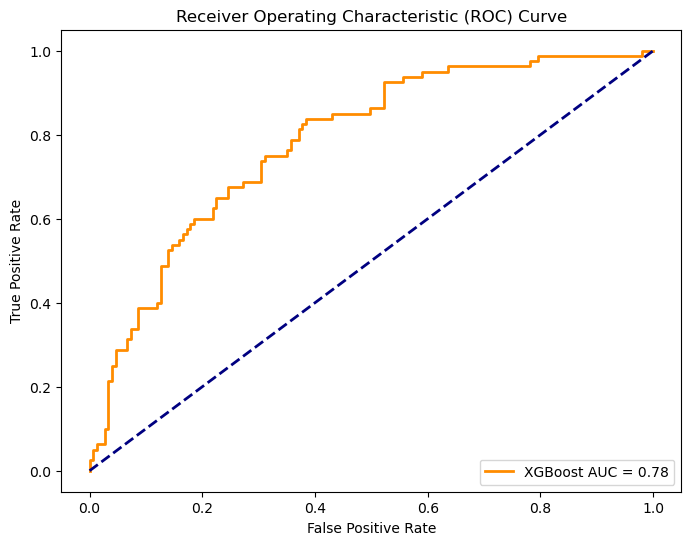

In [12]:
# 5. ROC Curve
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"XGBoost AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

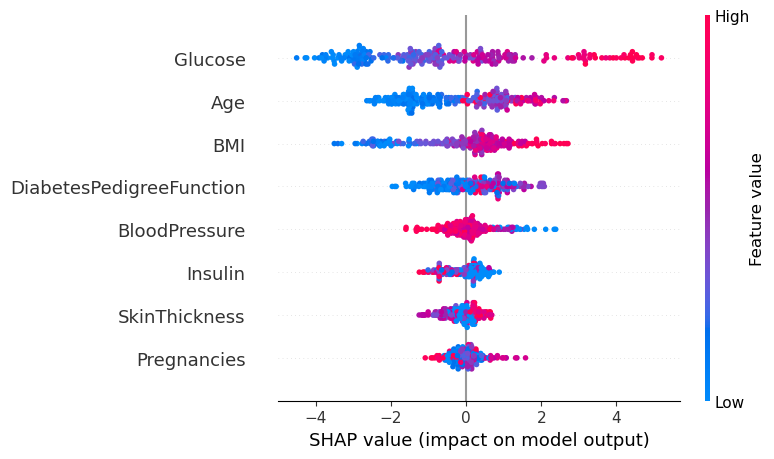

In [13]:
# 6. SHAP - Global Explainability
explainer_shap = shap.Explainer(best_model)
shap_values = explainer_shap(X_test_scaled)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

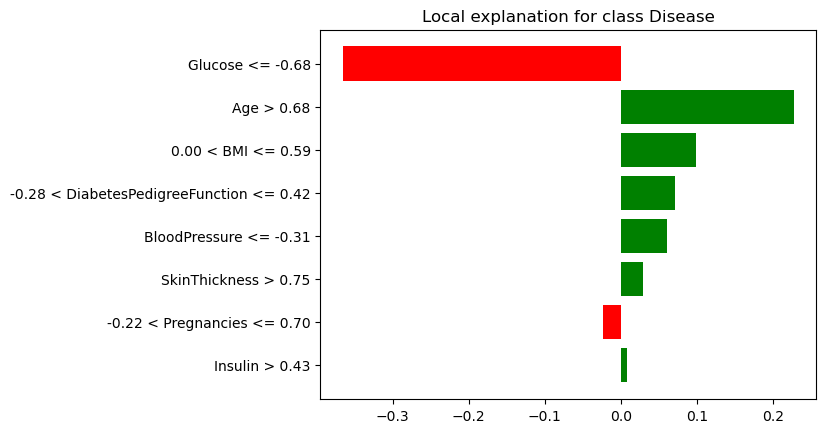


All figures (Confusion Matrix, ROC Curve, SHAP, LIME) generated successfully!


In [15]:
# 7. LIME - Local Explainability
explainer_lime = LimeTabularExplainer(
    X_train_scaled.values,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    mode="classification",
    random_state=42
)

i = 0 # Explaining the first patient in the test set
exp = explainer_lime.explain_instance(X_test_scaled.iloc[i].values, best_model.predict_proba)
# Save as HTML for interactive viewing, and as an image for the paper
exp.save_to_file("lime_explanation.html")
fig = exp.as_pyplot_figure()
fig.savefig("lime_explanation.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nAll figures (Confusion Matrix, ROC Curve, SHAP, LIME) generated successfully!")